In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open('results_experiment2/misclassification_analysis.json') as f:
    results = json.load(f)

summary = results['summary']
vs_true = results['misclassified_vs_true_concepts']
vs_pred = results['misclassified_vs_predicted_class_concepts']
baseline = results['correctly_classified_baseline']

print(f"Total images: {summary['total_images']}")
print(f"Correctly classified: {summary['correctly_classified']} ({summary['accuracy_rate']*100:.1f}%)")
print(f"Misclassified: {summary['misclassified']} ({(1 - summary['accuracy_rate'])*100:.1f}%)")

Total images: 5794
Correctly classified: 4304 (74.3%)
Misclassified: 1490 (25.7%)


## Classification Summary

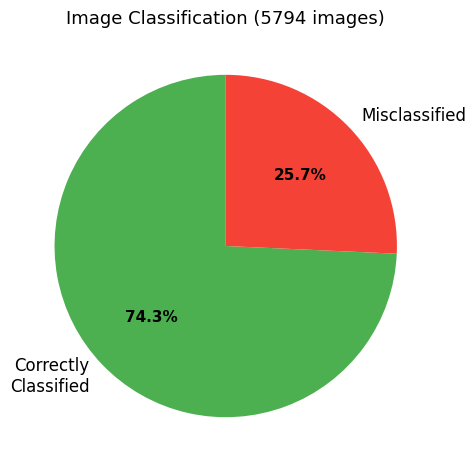

In [2]:
fig, ax = plt.subplots(figsize=(5, 5))
counts = [summary['correctly_classified'], summary['misclassified']]
labels = ['Correctly\nClassified', 'Misclassified']
colors = ['#4CAF50', '#F44336']
wedges, texts, autotexts = ax.pie(
    counts, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 12}
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
ax.set_title(f'Image Classification ({summary["total_images"]} images)', fontsize=13)
plt.tight_layout()
plt.show()

## Concept Prediction Metrics Comparison

Compare predicted concepts against:
1. **Correctly Classified (Baseline)** - predicted concepts vs true class concepts for correctly classified images
2. **Misclassified vs True Class** - predicted concepts vs concepts of the TRUE class
3. **Misclassified vs Predicted Class** - predicted concepts vs concepts of the PREDICTED (wrong) class

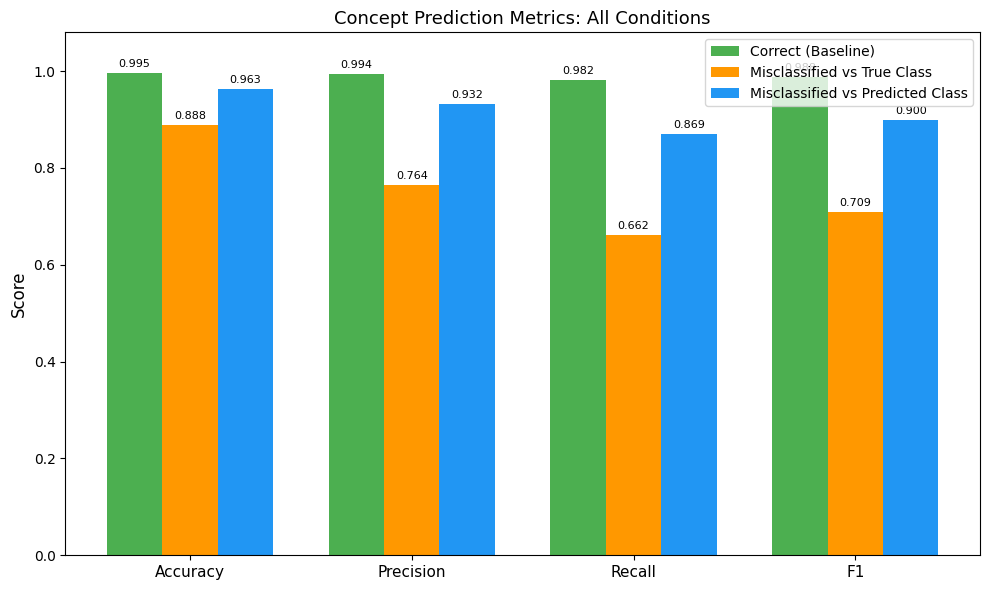

In [3]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
metric_keys = ['accuracy', 'precision', 'recall', 'f1']

baseline_vals = [baseline[k] for k in metric_keys]
vs_true_vals = [vs_true[k] for k in metric_keys]
vs_pred_vals = [vs_pred[k] for k in metric_keys]

x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, baseline_vals, width, label='Correct (Baseline)', color='#4CAF50')
bars2 = ax.bar(x, vs_true_vals, width, label='Misclassified vs True Class', color='#FF9800')
bars3 = ax.bar(x + width, vs_pred_vals, width, label='Misclassified vs Predicted Class', color='#2196F3')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Concept Prediction Metrics: All Conditions', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.08)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Individual Metric Comparisons

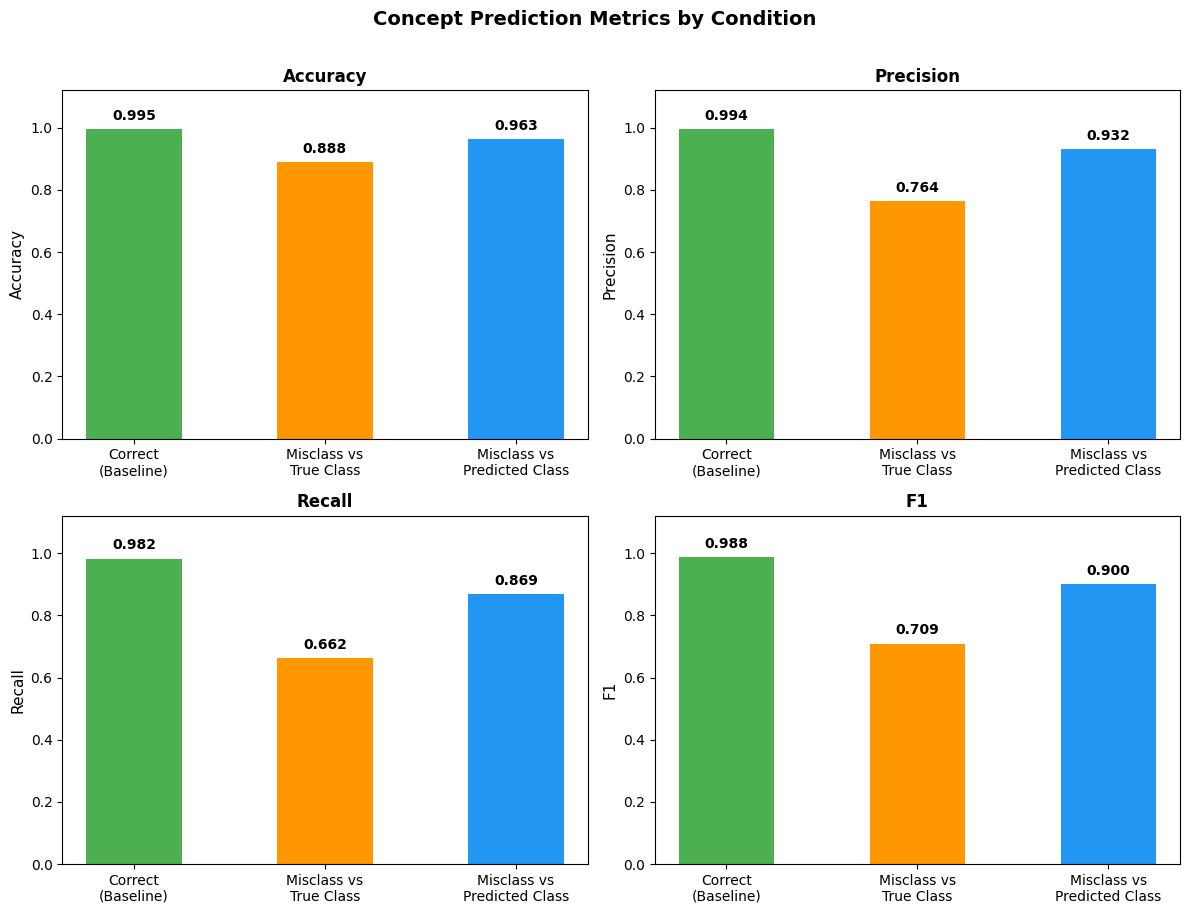

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

group_labels = ['Correct\n(Baseline)', 'Misclass vs\nTrue Class', 'Misclass vs\nPredicted Class']
colors = ['#4CAF50', '#FF9800', '#2196F3']

for i, (mname, mkey) in enumerate(zip(metric_names, metric_keys)):
    ax = axes[i // 2][i % 2]
    vals = [baseline[mkey], vs_true[mkey], vs_pred[mkey]]
    bars = ax.bar(group_labels, vals, color=colors, width=0.5)
    ax.set_ylabel(mname, fontsize=11)
    ax.set_title(mname, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.12)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Concept Prediction Metrics by Condition', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Metric Gaps: Misclassified vs True Class vs Predicted Class

Shows how much better the predicted concepts match the predicted (wrong) class compared to the true class. Positive values support the hypothesis.

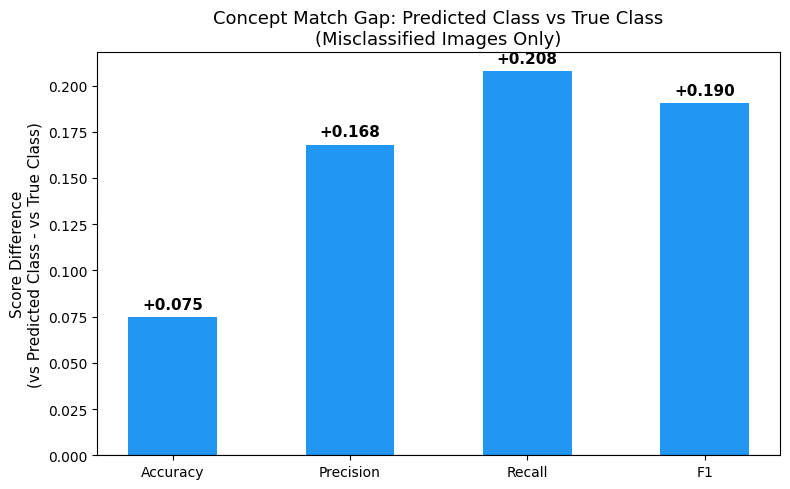

In [5]:
deltas = [vs_pred[k] - vs_true[k] for k in metric_keys]

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#2196F3' if d > 0 else '#F44336' for d in deltas]
bars = ax.bar(metric_names, deltas, color=bar_colors, width=0.5)

for bar, d in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.003 if d >= 0 else -0.008),
            f'+{d:.3f}' if d > 0 else f'{d:.3f}',
            ha='center', va='bottom' if d >= 0 else 'top', fontsize=11, fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Score Difference\n(vs Predicted Class - vs True Class)', fontsize=11)
ax.set_title('Concept Match Gap: Predicted Class vs True Class\n(Misclassified Images Only)', fontsize=13)
plt.tight_layout()
plt.show()

## Drop from Baseline

How much do concept prediction metrics degrade compared to the correctly-classified baseline?

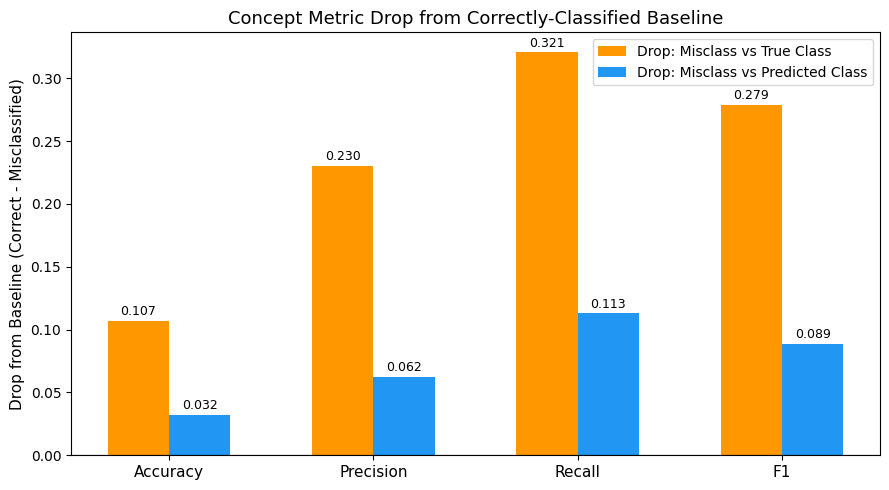

In [6]:
drop_vs_true = [baseline[k] - vs_true[k] for k in metric_keys]
drop_vs_pred = [baseline[k] - vs_pred[k] for k in metric_keys]

x = np.arange(len(metric_names))
width = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, drop_vs_true, width, label='Drop: Misclass vs True Class', color='#FF9800')
bars2 = ax.bar(x + width/2, drop_vs_pred, width, label='Drop: Misclass vs Predicted Class', color='#2196F3')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.002,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Drop from Baseline (Correct - Misclassified)', fontsize=11)
ax.set_title('Concept Metric Drop from Correctly-Classified Baseline', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Misclassification Examples

In [7]:
examples = results['misclassification_examples']

# Print table
print(f"{'True Class':<35} {'Predicted Class':<35}")
print('-' * 70)
for ex in examples:
    print(f"{ex['y_true_name']:<35} {ex['y_pred_name']:<35}")

True Class                          Predicted Class                    
----------------------------------------------------------------------
001.Black_footed_Albatross          003.Sooty_Albatross                
001.Black_footed_Albatross          071.Long_tailed_Jaeger             
001.Black_footed_Albatross          072.Pomarine_Jaeger                
001.Black_footed_Albatross          003.Sooty_Albatross                
001.Black_footed_Albatross          003.Sooty_Albatross                
001.Black_footed_Albatross          003.Sooty_Albatross                
002.Laysan_Albatross                066.Western_Gull                   
002.Laysan_Albatross                106.Horned_Puffin                  
002.Laysan_Albatross                066.Western_Gull                   
002.Laysan_Albatross                011.Rusty_Blackbird                
002.Laysan_Albatross                064.Ring_billed_Gull               
002.Laysan_Albatross                063.Ivory_Gull               

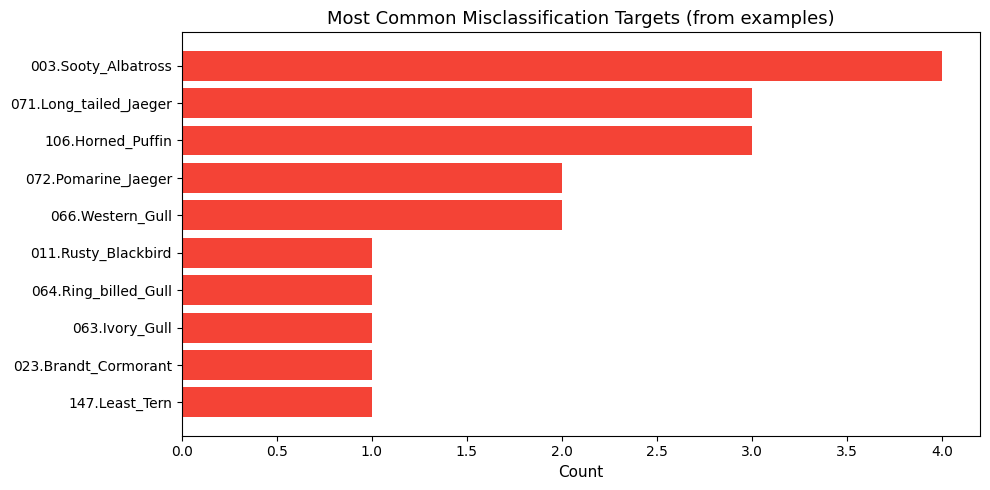

In [8]:
# Count most common misclassification targets
from collections import Counter

pred_counts = Counter(ex['y_pred_name'] for ex in examples)
top_preds = pred_counts.most_common(10)

if top_preds:
    labels_top, counts_top = zip(*top_preds)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(len(labels_top)), counts_top, color='#F44336')
    ax.set_yticks(range(len(labels_top)))
    ax.set_yticklabels(labels_top, fontsize=10)
    ax.set_xlabel('Count', fontsize=11)
    ax.set_title('Most Common Misclassification Targets (from examples)', fontsize=13)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## Per-Concept Metrics

Confusion matrix-derived metrics for each individual concept across all three conditions.

In [11]:
results

{'summary': {'total_images': 5794,
  'correctly_classified': 4304,
  'misclassified': 1490,
  'accuracy_rate': 0.74283741801864},
 'misclassified_vs_true_concepts': {'description': 'Predicted concepts compared to concepts of TRUE class (y_true)',
  'n_concept_comparisons': 166880,
  'accuracy': 0.888183125599233,
  'precision': 0.7640400376192396,
  'recall': 0.6615961840497935,
  'f1': 0.7091373881597406},
 'misclassified_vs_predicted_class_concepts': {'description': 'Predicted concepts compared to concepts of PREDICTED class (y_pred)',
  'n_concept_comparisons': 166880,
  'accuracy': 0.9628655321188878,
  'precision': 0.9320166599489453,
  'recall': 0.8692710128128818,
  'f1': 0.8995510025448592},
 'correctly_classified_baseline': {'description': 'Baseline: Predicted concepts compared to true concepts for correctly classified images',
  'n_concept_comparisons': 482048,
  'accuracy': 0.9952266164365374,
  'precision': 0.9944362322411103,
  'recall': 0.9821662121196759,
  'f1': 0.98826

In [10]:
per_concept = results['per_concept']
concept_names = list(per_concept.keys())
print(f"Loaded per-concept metrics for {len(concept_names)} concepts")

def cm_metrics(cm):
    """Compute accuracy, precision, recall, F1 from confusion matrix dict."""
    tp, fp, tn, fn = cm['tp'], cm['fp'], cm['tn'], cm['fn']
    total = tp + fp + tn + fn
    acc = (tp + tn) / total if total > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    return acc, prec, rec, f1

# Precompute per-concept metrics for all three conditions
conditions = ['baseline', 'vs_true', 'vs_predicted_class']
cond_labels = ['Correct (Baseline)', 'Misclassified vs True Class', 'Misclassified vs Predicted Class']

pc_metrics = {}  # pc_metrics[condition][concept_name] = (acc, prec, rec, f1)
for cond in conditions:
    pc_metrics[cond] = {}
    for cn in concept_names:
        pc_metrics[cond][cn] = cm_metrics(per_concept[cn][cond])

print("Per-concept metrics computed")

KeyError: 'per_concept'

### Per-Concept Accuracy

In [ ]:
def per_concept_bar_plot(concept_names, pc_metrics, metric_idx, metric_name, conditions, cond_labels):
    """Bar plot for a single metric across all concepts and conditions."""
    x = np.arange(len(concept_names))
    width = 0.25
    colors = ['#4CAF50', '#FF9800', '#2196F3']

    fig, ax = plt.subplots(figsize=(max(14, len(concept_names) * 0.5), 6))
    for ci, (cond, label) in enumerate(zip(conditions, cond_labels)):
        vals = [pc_metrics[cond][cn][metric_idx] for cn in concept_names]
        ax.bar(x + ci * width, vals, width, label=label, color=colors[ci])

    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(f'Per-Concept {metric_name}', fontsize=13)
    ax.set_xticks(x + width)
    ax.set_xticklabels(concept_names, rotation=90, ha='center', fontsize=7)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

per_concept_bar_plot(concept_names, pc_metrics, 0, 'Accuracy', conditions, cond_labels)

### Per-Concept Recall, Precision, F1

In [ ]:
per_concept_bar_plot(concept_names, pc_metrics, 2, 'Recall', conditions, cond_labels)
per_concept_bar_plot(concept_names, pc_metrics, 1, 'Precision', conditions, cond_labels)
per_concept_bar_plot(concept_names, pc_metrics, 3, 'F1', conditions, cond_labels)

### Per-Concept Metric Gap (Predicted Class - True Class)

Positive values mean the predicted concepts match the predicted (wrong) class better than the true class for that concept.

In [ ]:
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']

for mi, mname in enumerate(metric_labels):
    deltas = [pc_metrics['vs_predicted_class'][cn][mi] - pc_metrics['vs_true'][cn][mi] for cn in concept_names]

    fig, ax = plt.subplots(figsize=(max(14, len(concept_names) * 0.5), 5))
    bar_colors = ['#2196F3' if d >= 0 else '#F44336' for d in deltas]
    ax.bar(range(len(concept_names)), deltas, color=bar_colors)
    ax.set_xticks(range(len(concept_names)))
    ax.set_xticklabels(concept_names, rotation=90, ha='center', fontsize=7)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_ylabel(f'{mname} Gap', fontsize=11)
    ax.set_title(f'Per-Concept {mname} Gap (vs Predicted Class - vs True Class)', fontsize=13)
    plt.tight_layout()
    plt.show()